In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

In [12]:
data = {
    "House Size": [600,800,1000,1200,1400,1600,1800,2000,2200,2400],
    "House Price": [25,32,38,45,52,58,65,72,80,87]
}

df = pd.DataFrame(data)

print("Dataset")
#print(df)
df.head()

Dataset


,House Size,House Price
0,600,25
1,800,32
2,1000,38
3,1200,45
4,1400,52


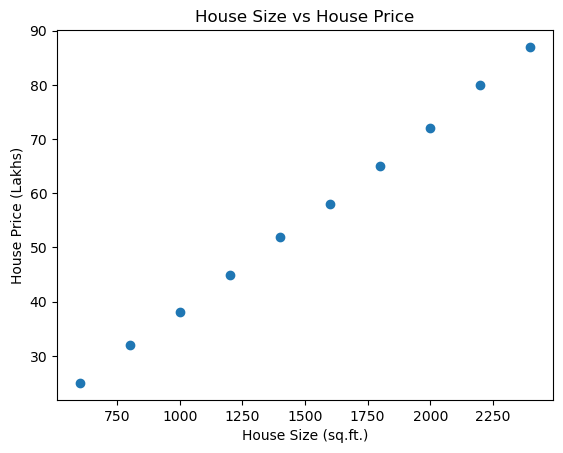

Observation: House price increases as house size increases.


In [3]:
plt.scatter(df["House Size"], df["House Price"])
plt.xlabel("House Size (sq.ft.)")
plt.ylabel("House Price (Lakhs)")
plt.title("House Size vs House Price")
plt.show()

print("Observation: House price increases as house size increases.")

In [4]:
X = df[["House Size"]]
y = df["House Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [13]:
print("\nRegression Constant (theta0):", model.intercept_)
print("Regression Coefficient (theta1):", model.coef_[0])


Regression Constant (theta0): 3.9137931034482705
Regression Coefficient (theta1): 0.03422413793103449


In [7]:
y_pred = model.predict(X_test)

print("\nActual vs Predicted")

result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(result)


Actual vs Predicted
   Actual  Predicted
0      80  79.206897
1      32  31.293103


In [8]:
new_sizes = pd.DataFrame({
    "House Size":[1500,1700,2500]
})

new_predictions = model.predict(new_sizes)

print("\nPredicted House Prices")

for size, price in zip(new_sizes["House Size"], new_predictions):
    print(size,"sq.ft. ->",round(price,2),"Lakhs")


Predicted House Prices
1500 sq.ft. -> 55.25 Lakhs
1700 sq.ft. -> 62.09 Lakhs
2500 sq.ft. -> 89.47 Lakhs


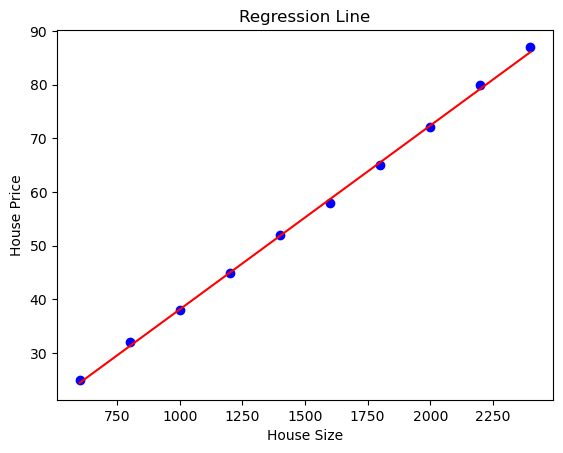

Observation: The regression line shows a positive linear relationship.


In [9]:
plt.scatter(X, y, color="blue")

plt.plot(
    X,
    model.predict(X),
    color="red"
)

plt.xlabel("House Size")
plt.ylabel("House Price")
plt.title("Regression Line")

plt.show()

print("Observation: The regression line shows a positive linear relationship.")

In [10]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = math.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("\nModel Evaluation")
print("MAE :",mae)
print("MSE :",mse)
print("RMSE:",rmse)
print("R2 Score:",r2)


Model Evaluation
MAE : 0.7499999999999982
MSE : 0.564357907253267
RMSE: 0.751237583759803
R2 Score: 0.9990202119665742


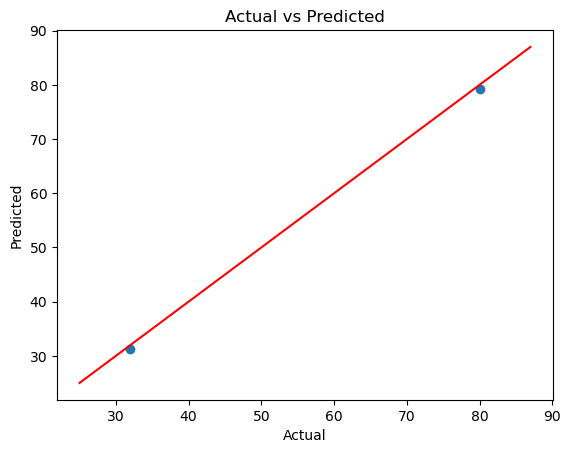

Observation: Predicted values are close to actual values, indicating good prediction accuracy.


In [11]:
plt.scatter(y_test,y_pred)

plt.plot(
    [y.min(),y.max()],
    [y.min(),y.max()],
    color="red"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()
print("Observation: Predicted values are close to actual values, indicating good prediction accuracy.")